# Road Accident Severity Prediction Using Machine Learning

###   A Multi-Class Classification Project

*Project Type:* Machine Learning Project

**Dataset:** Road Traffic Accident (RTA) Dataset

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn

**Objective:**
To build a Machine Learning model that predicts the severity of road accidents (Slight Injury, Serious Injury, or Fatal Injury) using driver, vehicle, road, and environmental information.

In [414]:

# 1 : Import Required Libraries

# Data manipulation libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Display graphs i
%matplotlib inline

# Set visualization style
plt.style.use("ggplot")


# Import Label Encoder
from sklearn.preprocessing import LabelEncoder


# Import Train-Test Split
from sklearn.model_selection import train_test_split


# Import Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Import Evaluation Metrics
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix)

print(" All libraries imported successfully.")

 All libraries imported successfully.


In [415]:

# 2 : Load the Dataset 

# Load the dataset
df = pd.read_csv("RTA Dataset.csv")

# Display first five records
df.head()


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [416]:
# Display number of rows and columns

print("Dataset Shape :", df.shape)

# Display last five rows

df.tail()

Dataset Shape : (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury
12315,13:55:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Other,Owner,2-5yrs,...,Stopping,Pedestrian,Female,5,3,Driver,Normal,Crossing from nearside - masked by parked or s...,Changing lane to the right,Slight Injury


In [417]:

# 3 : Basic Dataset Information

# Display dataset information

df.info()

# Display data types of each column

df.dtypes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

Time                           object
Day_of_week                    object
Age_band_of_driver             object
Sex_of_driver                  object
Educational_level              object
Vehicle_driver_relation        object
Driving_experience             object
Type_of_vehicle                object
Owner_of_vehicle               object
Service_year_of_vehicle        object
Defect_of_vehicle              object
Area_accident_occured          object
Lanes_or_Medians               object
Road_allignment                object
Types_of_Junction              object
Road_surface_type              object
Road_surface_conditions        object
Light_conditions               object
Weather_conditions             object
Type_of_collision              object
Number_of_vehicles_involved     int64
Number_of_casualties            int64
Vehicle_movement               object
Casualty_class                 object
Sex_of_casualty                object
Age_band_of_casualty           object
Casualty_sev

In [418]:
# Display all column names

df.columns.tolist()



['Time',
 'Day_of_week',
 'Age_band_of_driver',
 'Sex_of_driver',
 'Educational_level',
 'Vehicle_driver_relation',
 'Driving_experience',
 'Type_of_vehicle',
 'Owner_of_vehicle',
 'Service_year_of_vehicle',
 'Defect_of_vehicle',
 'Area_accident_occured',
 'Lanes_or_Medians',
 'Road_allignment',
 'Types_of_Junction',
 'Road_surface_type',
 'Road_surface_conditions',
 'Light_conditions',
 'Weather_conditions',
 'Type_of_collision',
 'Number_of_vehicles_involved',
 'Number_of_casualties',
 'Vehicle_movement',
 'Casualty_class',
 'Sex_of_casualty',
 'Age_band_of_casualty',
 'Casualty_severity',
 'Work_of_casuality',
 'Fitness_of_casuality',
 'Pedestrian_movement',
 'Cause_of_accident',
 'Accident_severity']

In [419]:

print("Number of Rows :", df.shape[0])

print("Number of Columns :", df.shape[1])

Number of Rows : 12316
Number of Columns : 32


In [420]:

# Step 4.1 : Statistical Summary

# Display statistical summary of numerical columns

df.describe()


,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [421]:
# Step 4.2 : Summary of Categorical Columns

df.describe(include='object')


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,11575,11737,11487,11366,11834,8388,...,12008,12316,12316,12316,12316,9118,9681,12316,12316,12316
unique,1074,7,5,3,7,4,7,17,4,6,...,13,4,3,6,4,7,5,9,20,3
top,15:30:00,Friday,18-30,Male,Junior high school,Employee,5-10yr,Automobile,Owner,Unknown,...,Going straight,Driver or rider,Male,na,3,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
freq,120,2041,4271,11437,7619,9627,3363,3205,10459,2883,...,8158,4944,5253,4443,7076,5903,9608,11390,2263,10415


In [422]:

# Step 4.3 : Check Duplicate Records

duplicate_rows = df.duplicated().sum()

print("Total Duplicate Records :", duplicate_rows)


Total Duplicate Records : 0


In [423]:

# Step 4.4 : Accident Severity Distribution

severity_count = df["Accident_severity"].value_counts()

print(severity_count)

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


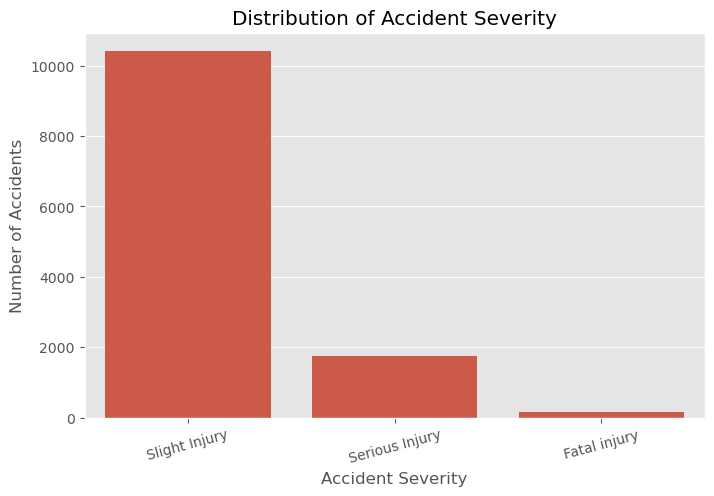

In [424]:

# Step 4.5 : Visualize Accident Severity Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Accident_severity",
    order=df["Accident_severity"].value_counts().index
)

plt.title("Distribution of Accident Severity")

plt.xlabel("Accident Severity")

plt.ylabel("Number of Accidents")

plt.xticks(rotation=15)

plt.show()

In [425]:

# Step 4.6 : Percentage Distribution

severity_percentage = (
    df["Accident_severity"]
    .value_counts(normalize=True) * 100
)

print(severity_percentage.round(2))

Accident_severity
Slight Injury     84.56
Serious Injury    14.15
Fatal injury       1.28
Name: proportion, dtype: float64


In [426]:
# Step 4.7 : Missing Values

missing_values = df.isnull().sum()

missing_values

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [427]:

# Step 4.8 : Columns Having Missing Values

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Values"] > 0]

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Defect_of_vehicle,4427,35.945112
Service_year_of_vehicle,3928,31.893472
Work_of_casuality,3198,25.966223
Fitness_of_casuality,2635,21.394933
Type_of_vehicle,950,7.713543
Types_of_Junction,887,7.202014
Driving_experience,829,6.731082
Educational_level,741,6.016564
Vehicle_driver_relation,579,4.701202
Owner_of_vehicle,482,3.913608


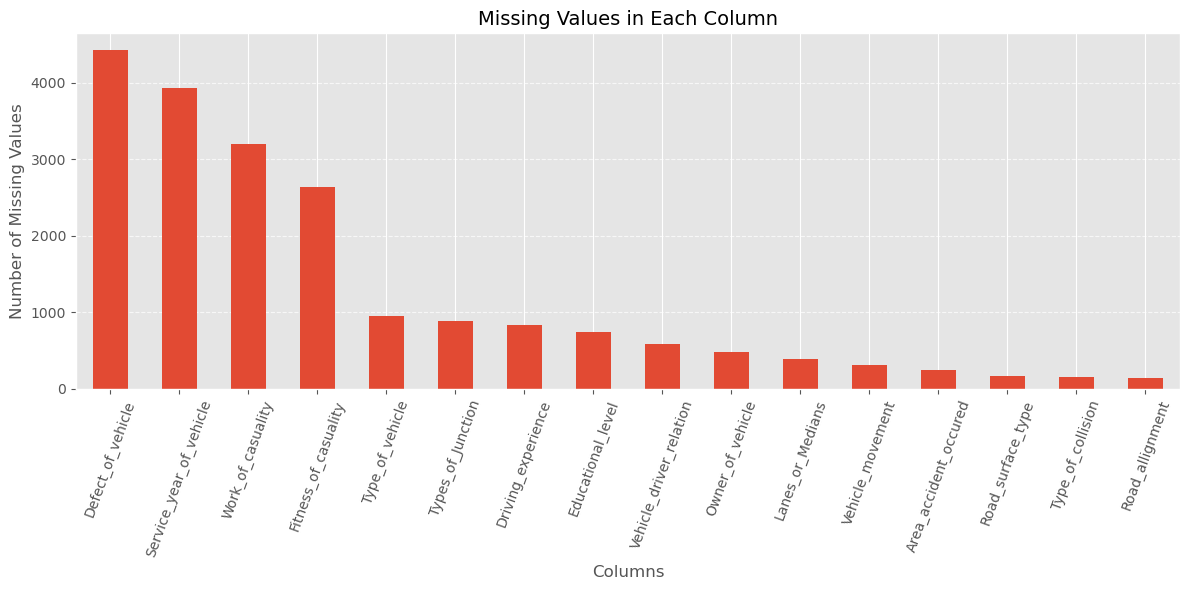

In [428]:

# Step 4.9 : Missing Values Visualization

# Calculate missing values
missing_values = df.isnull().sum()

# Keep only columns with missing values
missing_values = missing_values[missing_values > 0]

# Sort values in descending order
missing_values = missing_values.sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,6))

missing_values.plot(kind='bar')

plt.title("Missing Values in Each Column", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=70)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

In [429]:

# Step 5.1 : Identify Categorical and Numerical Columns

# Select categorical columns
categorical_columns = df.select_dtypes(include='object').columns

# Select numerical columns
numerical_columns = df.select_dtypes(exclude='object').columns

print("Categorical Columns :", len(categorical_columns))
print("Numerical Columns   :", len(numerical_columns))

Categorical Columns : 30
Numerical Columns   : 2


In [430]:

# Step 5.2 : Fill Missing Values in Numerical Columns


for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

print(" Missing values in numerical columns filled successfully.")

 Missing values in numerical columns filled successfully.


In [431]:

# Step 5.3 : Verify Missing Values

missing_values = df.isnull().sum().sum()

print("Total Missing Values :", missing_values)


# Step 5.4 : Missing Values After Cleaning

df.isnull().sum()

Total Missing Values : 20057


Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [432]:
# Part 6 : Feature Engineering & Feature Selection
# Step 6.1 : Display Time Column

# Display first five values of Time column

df["Time"].head()

0    17:02:00
1    17:02:00
2    17:02:00
3     1:06:00
4     1:06:00
Name: Time, dtype: object

In [433]:

# Step 6.2 : Extract Hour from Time

# Convert Time column into datetime format
df["Time"] = pd.to_datetime(df["Time"])

# Create new Hour column
df["Hour"] = df["Time"].dt.hour

# Display first five values
df[["Time", "Hour"]].head()

,Time,Hour
0,2026-07-29 17:02:00,17
1,2026-07-29 17:02:00,17
2,2026-07-29 17:02:00,17
3,2026-07-29 01:06:00,1
4,2026-07-29 01:06:00,1


In [434]:

# Step 6.3 : Remove Original Time Column


df.drop("Time", axis=1, inplace=True)

print(" Time column removed successfully.")



 Time column removed successfully.


In [435]:
df.columns.tolist()

['Day_of_week',
 'Age_band_of_driver',
 'Sex_of_driver',
 'Educational_level',
 'Vehicle_driver_relation',
 'Driving_experience',
 'Type_of_vehicle',
 'Owner_of_vehicle',
 'Service_year_of_vehicle',
 'Defect_of_vehicle',
 'Area_accident_occured',
 'Lanes_or_Medians',
 'Road_allignment',
 'Types_of_Junction',
 'Road_surface_type',
 'Road_surface_conditions',
 'Light_conditions',
 'Weather_conditions',
 'Type_of_collision',
 'Number_of_vehicles_involved',
 'Number_of_casualties',
 'Vehicle_movement',
 'Casualty_class',
 'Sex_of_casualty',
 'Age_band_of_casualty',
 'Casualty_severity',
 'Work_of_casuality',
 'Fitness_of_casuality',
 'Pedestrian_movement',
 'Cause_of_accident',
 'Accident_severity',
 'Hour']

In [436]:

# Step 6.4 : Remove Data Leakage Columns


columns_to_drop = [

    "Casualty_class",
    "Sex_of_casualty",
    "Age_band_of_casualty",
    "Casualty_severity",
    "Work_of_casuality",
    "Fitness_of_casuality"

]

df.drop(columns=columns_to_drop, inplace=True)

print(" Data leakage columns removed successfully.")

 Data leakage columns removed successfully.


In [437]:

# Step 6.5 : Remaining Columns

print("Total Remaining Columns :", len(df.columns))

df.columns.tolist()

Total Remaining Columns : 26


['Day_of_week',
 'Age_band_of_driver',
 'Sex_of_driver',
 'Educational_level',
 'Vehicle_driver_relation',
 'Driving_experience',
 'Type_of_vehicle',
 'Owner_of_vehicle',
 'Service_year_of_vehicle',
 'Defect_of_vehicle',
 'Area_accident_occured',
 'Lanes_or_Medians',
 'Road_allignment',
 'Types_of_Junction',
 'Road_surface_type',
 'Road_surface_conditions',
 'Light_conditions',
 'Weather_conditions',
 'Type_of_collision',
 'Number_of_vehicles_involved',
 'Number_of_casualties',
 'Vehicle_movement',
 'Pedestrian_movement',
 'Cause_of_accident',
 'Accident_severity',
 'Hour']

In [438]:

# Step 6.6 : Define Target Variable

target_column = "Accident_severity"

print("Target Column :", target_column)

Target Column : Accident_severity


In [439]:
# Part 7 : Encode Categorical Features


# Step 7.1 : Find Categorical Feature Columns

categorical_features = X.select_dtypes(include="object").columns

print("Categorical Features:\n")

for column in categorical_features:
    print(column)


Categorical Features:



In [440]:

# Step 7.2 : Label Encode Feature Columns


# Dictionary to store encoders
feature_encoders = {}

# Encode each categorical feature
for column in categorical_features:

    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(X[column])

    feature_encoders[column] = encoder

print(" All categorical feature columns encoded successfully.")

 All categorical feature columns encoded successfully.


In [441]:

# Step 7.3 : Encode Target Column

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print(" Target column encoded successfully.")

 Target column encoded successfully.


In [ ]:

# Step 7.4 : Target Class Mapping

mapping = dict(zip(target_encoder.classes_,
target_encoder.transform(target_encoder.classes_)))

print("Target Class Mapping:\n")

for key, value in mapping.items():
    print(f"{key}  -->  {value}")

Target Class Mapping:

0  -->  0
1  -->  1
2  -->  2


In [443]:

# Step 7.5 : Display Encoded Features

X.head()


,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Hour
0,1,0,1,0,0,0,0,3,3,2,...,0,3,2,3,2,2,2,5,9,17
1,1,1,1,4,0,3,11,3,2,2,...,0,3,2,8,2,2,2,5,16,17
2,1,0,1,4,0,0,5,3,6,2,...,0,3,2,2,2,2,2,5,0,17
3,3,0,1,4,0,2,11,0,6,2,...,0,0,2,8,2,2,2,5,1,1
4,3,0,1,4,0,1,17,3,2,2,...,0,0,2,8,2,2,2,5,16,1


In [444]:

# Step 7.6 : Display Encoded Target


print("First 10 Encoded Target Values:")

print(y[:10])

First 10 Encoded Target Values:
[2 2 1 2 2 2 2 2 2 1]


In [445]:

# Step 7.7 : Dataset Ready for Model Training


print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (12316, 25)
Target Shape : (12316,)


In [446]:
# Part 8 : Split Dataset into Training and Testing Sets

# Step 8.1 : Split Features and Target


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(" Dataset split successfully.")

 Dataset split successfully.


In [447]:

# Step 8.2 : Display Shape of Training and Testing Sets


print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)

print()


Training Feature Shape : (9852, 25)
Testing Feature Shape  : (2464, 25)



In [448]:

# Step 8.3 : Verify Class Distribution

print("Training Set Distribution:\n")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

print("\n-----------------------------\n")

print("Testing Set Distribution:\n")
print(pd.Series(y_test).value_counts(normalize=True).round(3))

Training Set Distribution:

2    0.846
1    0.141
0    0.013
Name: proportion, dtype: float64

-----------------------------

Testing Set Distribution:

2    0.846
1    0.142
0    0.013
Name: proportion, dtype: float64


In [449]:

# Step 8.4 : Dataset Ready for Model Training


print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print("\n Data is now ready for Machine Learning model training.")

Training Samples : 9852
Testing Samples  : 2464

 Data is now ready for Machine Learning model training.


In [450]:
# Part 9 : Machine Learning Model Training


# Step 9.1 : Train Logistic Regression Model

logistic_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

print(" Logistic Regression model trained successfully.")

 Logistic Regression model trained successfully.


In [451]:

# Step 9.2 : Train Decision Tree Model


decision_tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

print(" Decision Tree model trained successfully.")

 Decision Tree model trained successfully.


In [452]:

# Step 9.3 : Train Random Forest Model


random_forest_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

random_forest_model.fit(X_train, y_train)

print(" Random Forest model trained successfully.")

 Random Forest model trained successfully.


In [453]:

# Step 9.4 : Training Summary


print("All Machine Learning models have been trained successfully.")

print("\nModels Trained:")

print("1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")

All Machine Learning models have been trained successfully.

Models Trained:
1. Logistic Regression
2. Decision Tree
3. Random Forest


In [454]:

# Step 9.5 : Generate Predictions


logistic_prediction = logistic_model.predict(X_test)

decision_tree_prediction = decision_tree_model.predict(X_test)

random_forest_prediction = random_forest_model.predict(X_test)

print(" Predictions generated successfully.")

 Predictions generated successfully.


In [455]:

# Step 9.6 : Display Sample Predictions


print("Logistic Regression Predictions:")
print(logistic_prediction[:10])

print("\nDecision Tree Predictions:")
print(decision_tree_prediction[:10])

print("\nRandom Forest Predictions:")
print(random_forest_prediction[:10])

Logistic Regression Predictions:
[1 2 2 2 1 2 1 2 1 2]

Decision Tree Predictions:
[2 2 2 2 2 2 1 1 1 2]

Random Forest Predictions:
[2 2 2 2 2 2 2 2 2 2]


In [456]:
# Part 10 : Model Evaluation


# Step 10.1: Logistic Regression Evaluation


logistic_accuracy = accuracy_score(y_test, logistic_prediction)

print("Logistic Regression Accuracy : {:.2f}%".format(logistic_accuracy * 100))

print("\nClassification Report\n")

print(classification_report(y_test, logistic_prediction))

Logistic Regression Accuracy : 49.39%

Classification Report

              precision    recall  f1-score   support

           0       0.02      0.39      0.04        31
           1       0.17      0.32      0.22       349
           2       0.87      0.53      0.65      2084

    accuracy                           0.49      2464
   macro avg       0.35      0.41      0.30      2464
weighted avg       0.76      0.49      0.59      2464



In [457]:

# Step 10.2 : Decision Tree Evaluation


decision_tree_accuracy = accuracy_score(y_test, decision_tree_prediction)

print("Decision Tree Accuracy : {:.2f}%".format(decision_tree_accuracy * 100))

print("\nClassification Report\n")

print(classification_report(y_test, decision_tree_prediction))

Decision Tree Accuracy : 76.22%

Classification Report

              precision    recall  f1-score   support

           0       0.15      0.19      0.17        31
           1       0.23      0.24      0.24       349
           2       0.87      0.86      0.86      2084

    accuracy                           0.76      2464
   macro avg       0.42      0.43      0.42      2464
weighted avg       0.77      0.76      0.76      2464



In [458]:

# Step 10.3 : Random Forest Evaluation

random_forest_accuracy = accuracy_score(y_test, random_forest_prediction)

print("Random Forest Accuracy : {:.2f}%".format(random_forest_accuracy * 100))

print("\nClassification Report\n")

print(classification_report(y_test, random_forest_prediction))

Random Forest Accuracy : 84.78%

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       1.00      0.01      0.03       349
           2       0.85      1.00      0.92      2084

    accuracy                           0.85      2464
   macro avg       0.62      0.34      0.32      2464
weighted avg       0.86      0.85      0.78      2464



In [459]:

# Step 10.4 : Confusion Matrix

cm = confusion_matrix(y_test, random_forest_prediction)

print(cm)

[[   0    0   31]
 [   0    5  344]
 [   0    0 2084]]


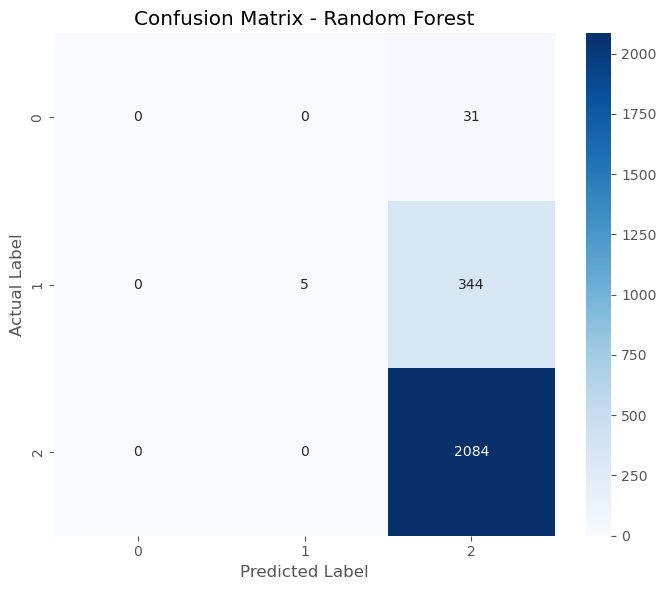

In [460]:

# Step 10.5 : Confusion Matrix Heatmap
import os
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()
plt.show()

In [461]:
# ==========================================================
# Step 10.6 : Model Accuracy Comparison
# ==========================================================

model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracy_scores = [
    logistic_accuracy,
    decision_tree_accuracy,
    random_forest_accuracy
]

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_scores
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.493912
1,Decision Tree,0.762175
2,Random Forest,0.847808


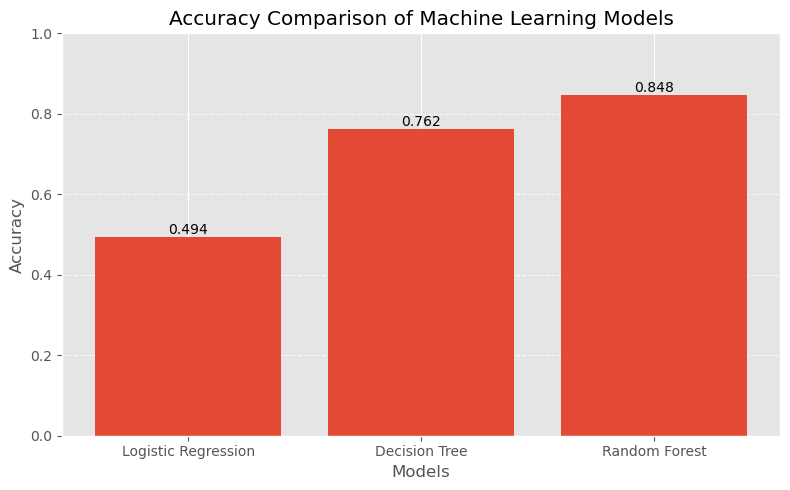

In [462]:
# ==========================================================
# Step 10.7: Accuracy Comparison Graph
# ==========================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Display accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom'
    )

plt.ylim(0, 1)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("images/accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()

In [463]:

# Step 10.8 : Best Performing Model


best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print("Best Model")

print("---------------------------")

print("Model :", best_model["Model"])

print("Accuracy :", round(best_model["Accuracy"] * 100, 2), "%")

Best Model
---------------------------
Model : Random Forest
Accuracy : 84.78 %


In [464]:
# Part 11 : Feature Importance Analysis

# Step 11.1 : Extract Feature Importance


feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance.head()

,Feature,Importance
0,Day_of_week,0.066879
1,Age_band_of_driver,0.048950
2,Sex_of_driver,0.006777
3,Educational_level,0.035360
4,Vehicle_driver_relation,0.018277


In [465]:

# Step 11.2 : Sort Features by Importance


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
24,Hour,0.099627
20,Number_of_casualties,0.089519
23,Cause_of_accident,0.070475
0,Day_of_week,0.066879
6,Type_of_vehicle,0.062052
19,Number_of_vehicles_involved,0.052178
13,Types_of_Junction,0.049141
1,Age_band_of_driver,0.048950
5,Driving_experience,0.048839
8,Service_year_of_vehicle,0.048664


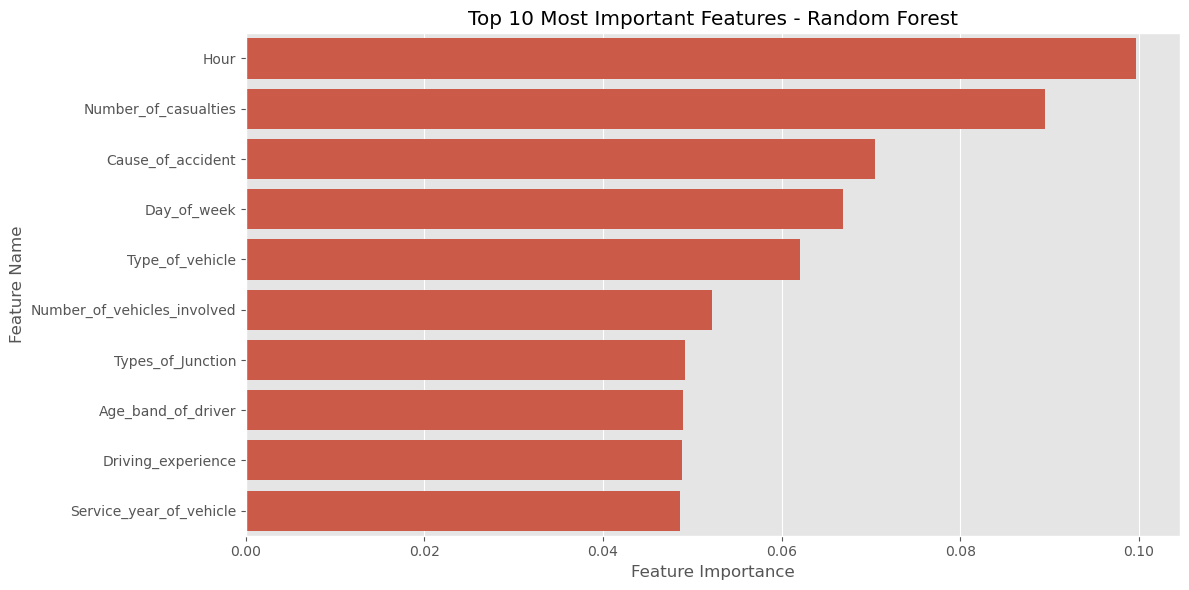

In [466]:

# Step 11.3 :  Feature Importance Visualization


plt.figure(figsize=(12,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")

plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

plt.show()

In [467]:
# Part 12 : Prediction on New Sample


# Step 12.1 : Create New Sample Data


sample_data = X.iloc[[0]].copy()

sample_data

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Hour
0,1,0,1,0,0,0,0,3,3,2,...,0,3,2,3,2,2,2,5,9,17


In [468]:

# Step 12.2 : Predict Accident Severity

prediction = random_forest_model.predict(sample_data)

print("Encoded Prediction :", prediction[0])

Encoded Prediction : 2


In [469]:

# Step 12.3 : Convert Prediction to Original Label


predicted_label = target_encoder.inverse_transform(prediction)

print("Predicted Accident Severity :", predicted_label[0])


Predicted Accident Severity : 2


In [470]:

# Step 12.4 : Prediction Summary

print("=" * 50)
print("ROAD ACCIDENT SEVERITY PREDICTION")
print("=" * 50)

print(f"Predicted Severity : {predicted_label[0]}")

print("=" * 50)

ROAD ACCIDENT SEVERITY PREDICTION
Predicted Severity : 2


In [471]:
# Part 13 : Save the Trained Model

# Step 13.1 : Import Joblib
import joblib



In [472]:

# Step 13.2 : Save Random Forest Model

joblib.dump(random_forest_model, "random_forest_model.pkl")

print(" Random Forest model saved successfully.")


# Step 13.3 : Save Feature Encoders

joblib.dump(feature_encoders, "feature_encoders.pkl")

print(" Feature encoders saved successfully.")


# Step 13.4 : Save Target Encoder

joblib.dump(target_encoder, "target_encoder.pkl")

print(" Target encoder saved successfully.")

 Random Forest model saved successfully.
 Feature encoders saved successfully.
 Target encoder saved successfully.


In [473]:

# Step 13.5 : Load Saved Model

loaded_model = joblib.load("random_forest_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.


In [474]:

# Step 13.6: Verify Loaded Model

loaded_prediction = loaded_model.predict(sample_data)

loaded_prediction = target_encoder.inverse_transform(loaded_prediction)

print("Prediction from Loaded Model:")
print(loaded_prediction[0])

Prediction from Loaded Model:
2


# Part 14 : Conclusion & Future Scope

## Project Conclusion

In this project, we developed a Machine Learning model to predict the severity of road traffic accidents using the Road Traffic Accident (RTA) dataset.

The project involved data preprocessing, exploratory data analysis, feature engineering, feature encoding, model training, and performance evaluation.

## Three Machine Learning algorithms were trained and compared:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

Among these models, the **Random Forest Classifier** achieved the best overall performance and was selected as the final prediction model.

The developed model can help identify accident severity based on available accident-related information and may support data-driven road safety analysis.

## Key Findings

- Successfully cleaned and preprocessed the dataset.
- Converted categorical features into numerical format using Label Encoding.
- Created a new feature (Hour) from the Time column.
- Compared three different Machine Learning models.
- Random Forest provided the highest prediction accuracy.
- Feature Importance analysis identified the most influential variables affecting accident severity.

In [475]:

# Step 14.1 : Best Model Summary


print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print(f"Best Model           : {best_model['Model']}")
print(f"Accuracy             : {best_model['Accuracy'] * 100:.2f}%")
print("Prediction Task      : Road Accident Severity Classification")
print("=" * 60)

FINAL PROJECT SUMMARY
Best Model           : Random Forest
Accuracy             : 84.78%
Prediction Task      : Road Accident Severity Classification


## Project Limitations

- The dataset contains missing values that required preprocessing.
- The model performance depends on the quality of the available data.
- Predictions are based only on the provided dataset and selected features.
- Real-time traffic, weather, and GPS information were not included.

## Future Scope

The project can be improved in the following ways:

- Collect larger and more diverse accident datasets.
- Include real-time weather and traffic information.
- Use advanced Machine Learning and Deep Learning algorithms such as XGBoost, LightGBM, or Neural Networks.
- Deploy the trained model as a web application using Streamlit or Flask.
- Integrate the model with smart traffic management systems for real-time accident severity prediction.

In [476]:

# Step 14.2: Project Completion Message


print("=" * 70)
print("🎉 ROAD ACCIDENT SEVERITY PREDICTION PROJECT COMPLETED 🎉")
print("=" * 70)
print("Thank you for exploring this Machine Learning project.")
print("The project demonstrates the complete workflow from")
print("data preprocessing to model deployment preparation.")
print("=" * 70)

🎉 ROAD ACCIDENT SEVERITY PREDICTION PROJECT COMPLETED 🎉
Thank you for exploring this Machine Learning project.
The project demonstrates the complete workflow from
data preprocessing to model deployment preparation.
